In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("dataset_hrv.csv")
df.head()

,record,window_start_sec,window_end_sec,mean_ibi,median_ibi,sdnn,rmssd,cv,mean_sd,std_sd,tpr,sd1,sd2,sd1_sd2,label
0,735,0.0,10.0,1090.5000,1084.0,20.2767,31.0576,1.8594,26.2857,33.4550,0.5000,23.6563,16.2070,1.4596,0
1,735,10.0,20.0,1120.0000,1128.0,36.7151,54.6260,3.2781,51.0000,57.2014,0.5714,40.4475,32.5576,1.2423,0
2,735,20.0,30.0,1140.8889,1140.0,29.5146,50.4183,2.5870,41.5000,53.8331,0.5714,38.0657,17.1237,2.2230,0
3,735,30.0,40.0,1116.4444,1108.0,47.8098,61.6117,4.2823,49.0000,65.8657,0.4286,46.5741,49.0144,0.9502,0
4,735,40.0,50.0,1134.2222,1132.0,34.1240,35.5809,3.0086,30.5000,37.3975,0.7143,26.4440,40.3683,0.6551,0


## `eda singkat`

<class 'pandas.DataFrame'>
RangeIndex: 87826 entries, 0 to 87825
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   record            87826 non-null  int64  
 1   window_start_sec  87826 non-null  float64
 2   window_end_sec    87826 non-null  float64
 3   mean_ibi          87826 non-null  float64
 4   median_ibi        87826 non-null  float64
 5   sdnn              87826 non-null  float64
 6   rmssd             87826 non-null  float64
 7   cv                87826 non-null  float64
 8   mean_sd           87826 non-null  float64
 9   std_sd            87826 non-null  float64
 10  tpr               87826 non-null  float64
 11  sd1               87826 non-null  float64
 12  sd2               87826 non-null  float64
 13  sd1_sd2           87826 non-null  float64
 14  label             87826 non-null  int64  
dtypes: float64(13), int64(2)
memory usage: 10.1 MB
None
label
0    53655
1    33668
2      503
Name: c

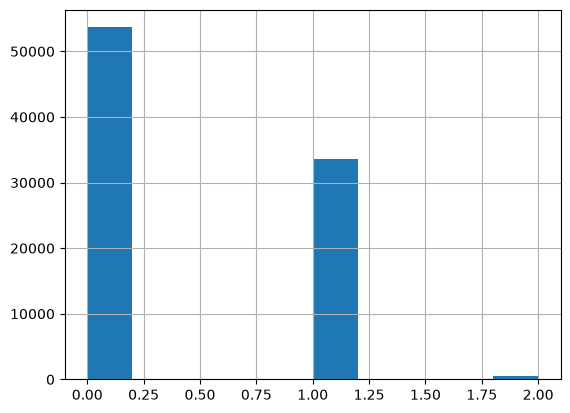

In [2]:
df['label'].hist()
print(df.info())
print(df['label'].value_counts())

In [3]:
df.isnull().sum()

record              0
window_start_sec    0
window_end_sec      0
mean_ibi            0
median_ibi          0
sdnn                0
rmssd               0
cv                  0
mean_sd             0
std_sd              0
tpr                 0
sd1                 0
sd2                 0
sd1_sd2             0
label               0
dtype: int64

In [4]:
df.describe(include='all')

,record,window_start_sec,window_end_sec,mean_ibi,median_ibi,sdnn,rmssd,cv,mean_sd,std_sd,tpr,sd1,sd2,sd1_sd2,label
count,87826.00000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,87826.000000,8.782600e+04,87826.000000
mean,6112.11434,17751.002095,17761.002095,773.749950,769.718580,82.675288,114.497447,11.487689,87.851259,118.937699,0.548933,84.101654,77.887378,8.794524e+02,0.394803
std,2001.59376,10363.455692,10363.455692,173.219256,178.751018,87.037414,123.628699,10.693924,96.043685,129.310728,0.182245,91.436493,85.586731,2.603096e+05,0.500391
min,735.00000,0.000000,10.000000,348.428600,286.000000,1.500400,1.460600,0.169200,0.533300,1.407500,0.000000,0.995200,0.000000,0.000000e+00,0.000000
25%,4746.00000,8780.000000,8790.000000,619.500000,612.000000,13.548600,15.849300,1.681950,13.090900,16.424900,0.437500,11.614200,14.477725,7.380000e-01,0.000000
50%,6426.00000,17570.000000,17580.000000,769.230800,772.000000,61.151650,82.592200,9.223100,56.615400,85.139150,0.555600,60.202450,55.061900,9.936000e-01,0.000000
75%,7910.00000,26710.000000,26720.000000,912.000000,912.000000,136.206375,189.019500,20.247250,143.200000,195.626450,0.666700,138.328775,125.461425,1.295900e+00,1.000000
max,8455.00000,36810.000000,36820.000000,3962.666700,2140.000000,5910.928600,7249.285800,243.799300,5140.000000,7269.057700,1.000000,5140.000000,6592.310300,7.714393e+07,2.000000


## `eda mendalam`

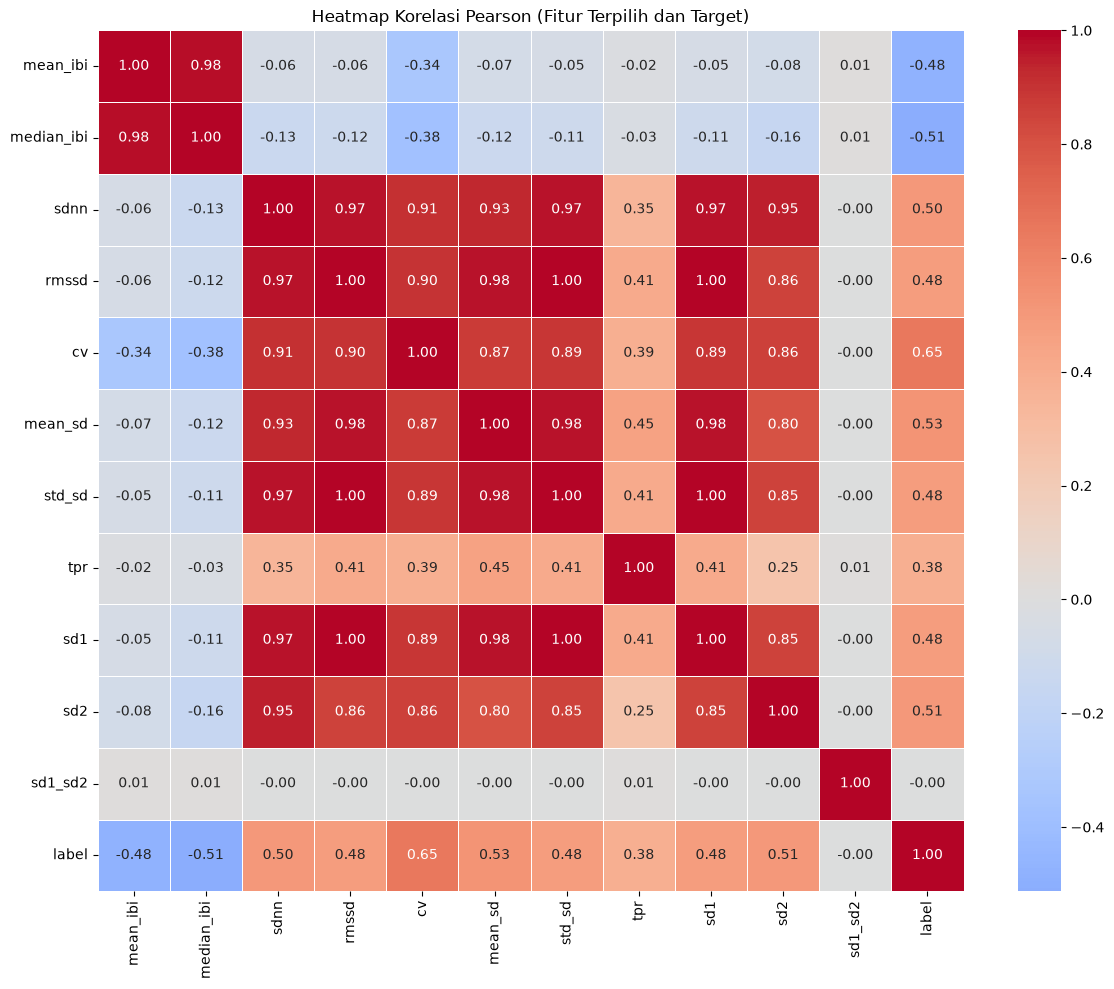

In [5]:
selected_cols = ['mean_ibi', 'median_ibi', 'sdnn', 'rmssd', 'cv', 'mean_sd', 'std_sd', 'tpr', 'sd1', 'sd2', 'sd1_sd2', 'label']
plt.figure(figsize=(12, 10))
sns.heatmap(
    df[selected_cols].corr(method="pearson"),
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Heatmap Korelasi Pearson (Fitur Terpilih dan Target)")
plt.tight_layout()
plt.show()

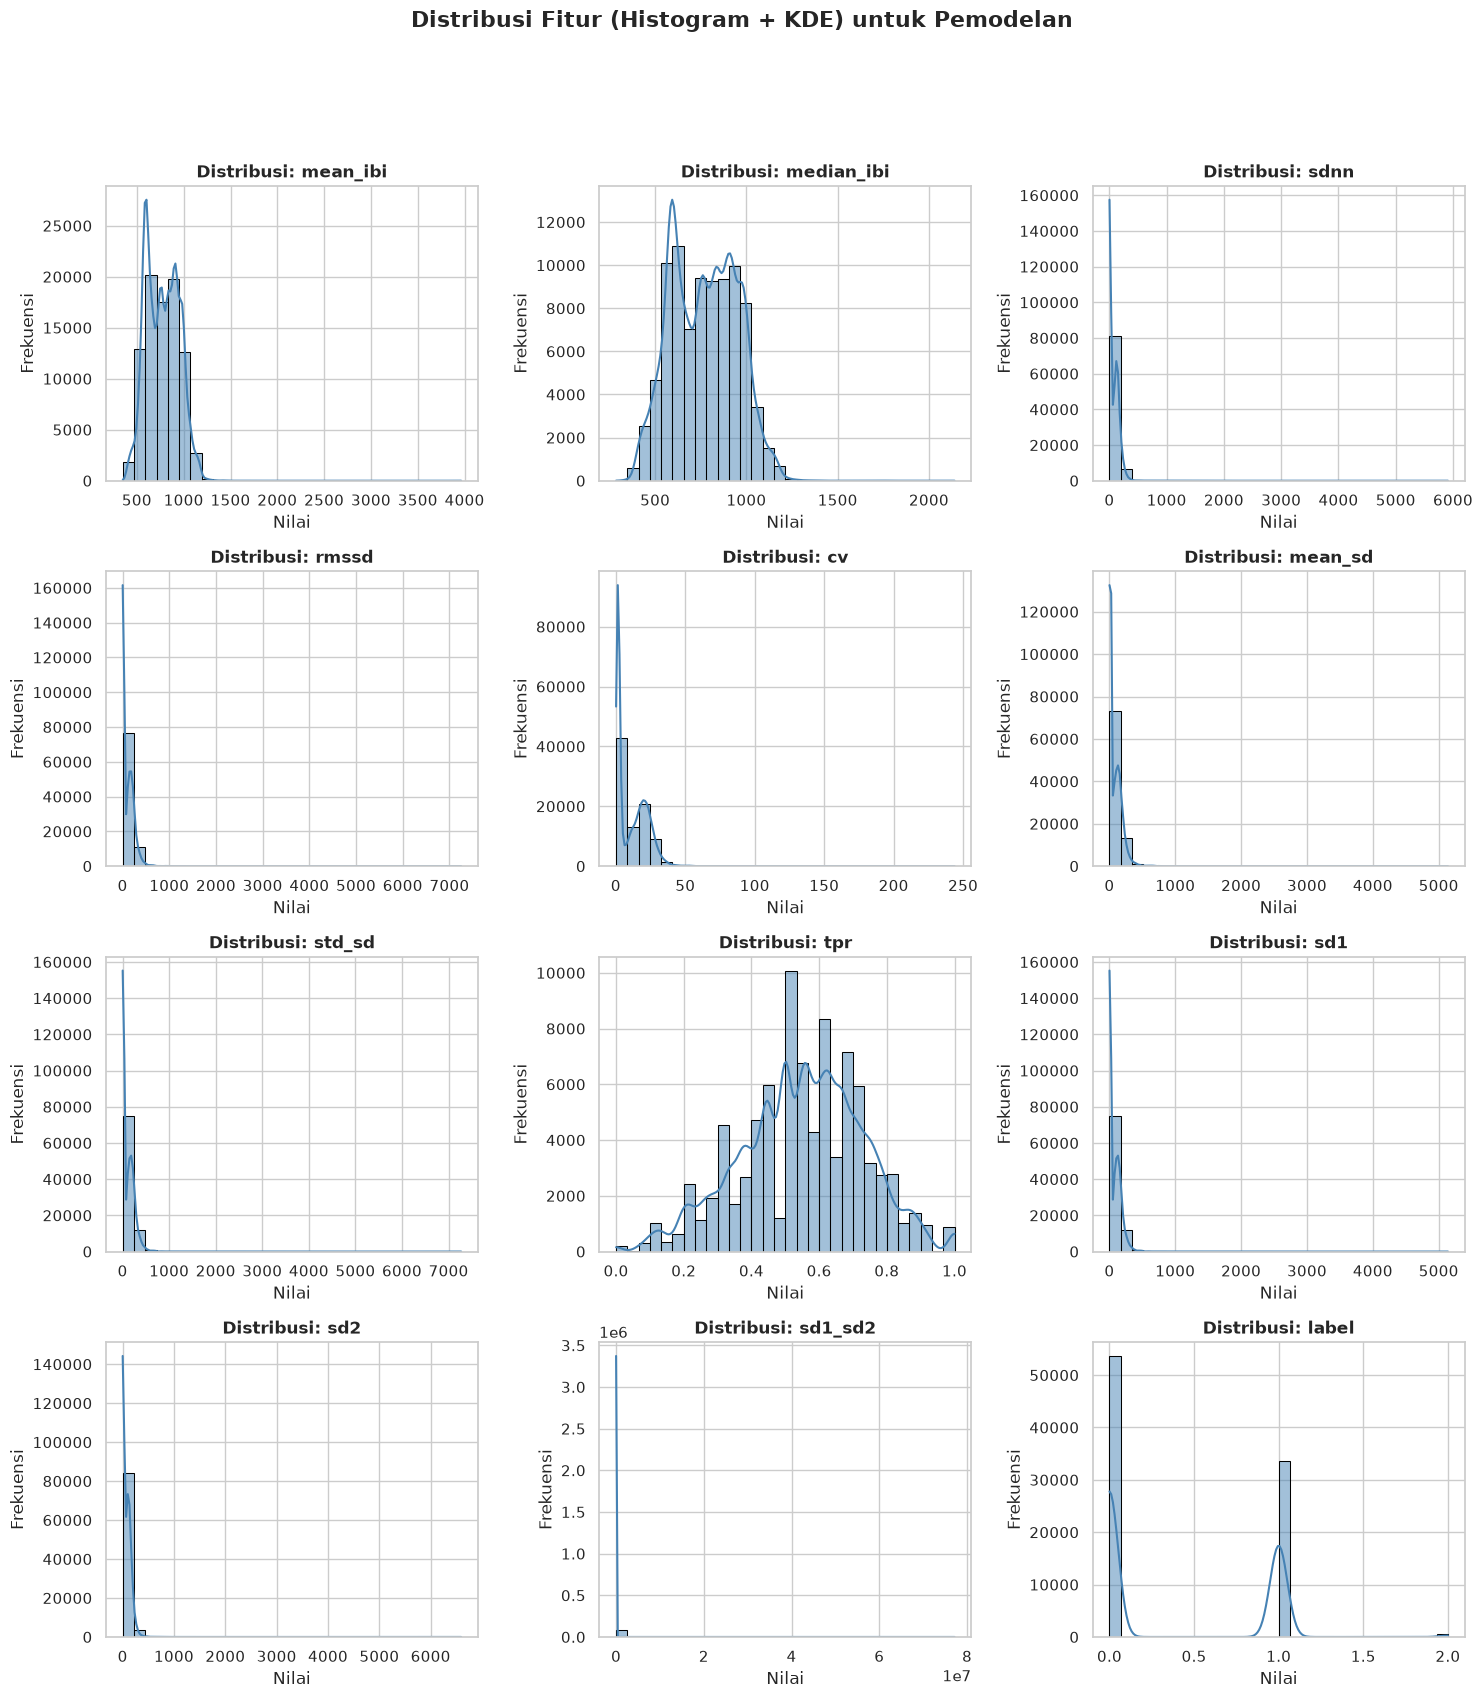

In [6]:
from scipy.stats import zscore
from IPython.display import display
import math

# Fitur yang digunakan untuk pemodelan (tanpa target label)
df_features = df[selected_cols]

sns.set_theme(style="whitegrid")

# 1. Menghitung dimensi grid (baris x kolom) secara dinamis
# Misal kita ingin membaginya menjadi 3 kolom agar rapi di layar
n_cols = len(df_features.columns)
ncols_grid = 3 
nrows_grid = math.ceil(n_cols / ncols_grid)

# 2. Inisialisasi Figure dan Axes (Object-Oriented API)
# Tinggi figure disesuaikan dinamis berdasarkan jumlah baris (4 inch per baris)
fig, axes = plt.subplots(nrows=nrows_grid, ncols=ncols_grid, figsize=(15, 4 * nrows_grid))

# Meratakan array axes dari 2D ke 1D agar mudah di-looping
axes = axes.flatten() 

# 3. Looping untuk menggambar histogram + KDE di setiap subplot
for i, col in enumerate(df_features.columns):
    sns.histplot(data=df_features, x=col, kde=True, bins=30, ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].set_title(f"Distribusi: {col}", fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Frekuensi")
    axes[i].set_xlabel("Nilai")

# 4. Menghapus subplot yang kosong (jika jumlah fitur tidak habis dibagi 3)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. Merapikan layout dan menampilkan hasil
plt.suptitle("Distribusi Fitur (Histogram + KDE) untuk Pemodelan", y=1.02 + (0.01 * nrows_grid), fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()



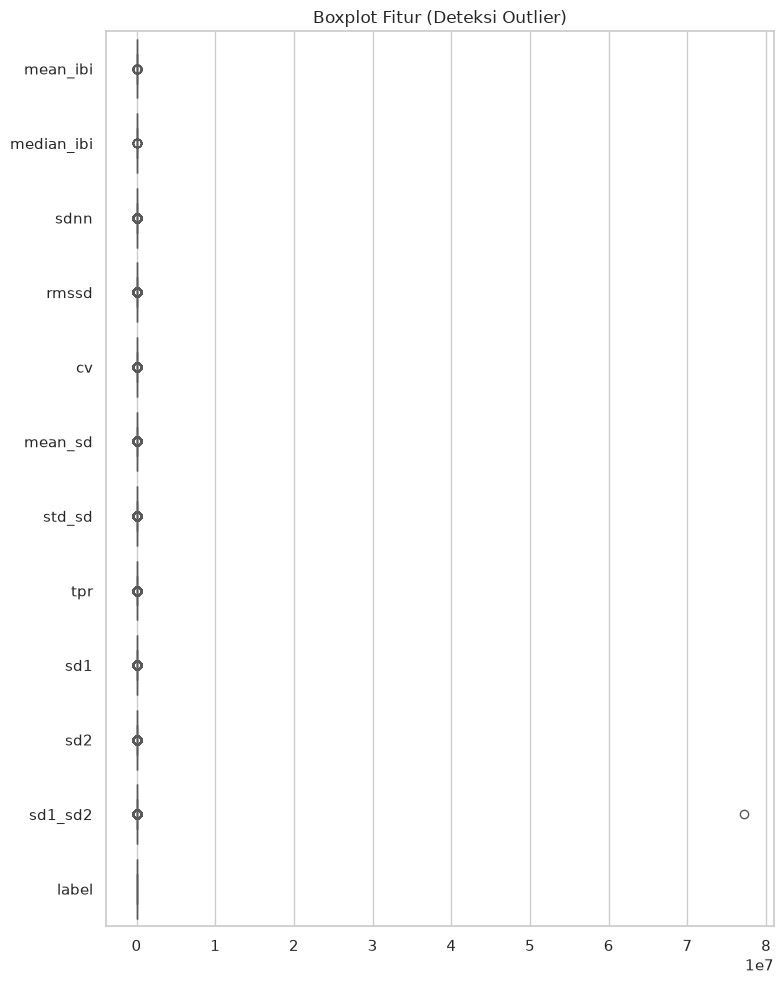

In [7]:
# 2. Mendeteksi Outlier Menggunakan Boxplot
plt.figure(figsize=(8, 10))
sns.boxplot(data=df_features, orient="h", palette="Set2")
plt.title("Boxplot Fitur (Deteksi Outlier)")
plt.tight_layout()
plt.show()

## `Preprocessing & modelling`

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PowerTransformer, RobustScaler,StandardScaler,FunctionTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import classification_report

from custom_transformers import IQRClipper
# Definisikan semua fitur HRV numerik yang akan diproses
numeric_features = ['mean_ibi', 'median_ibi', 'sdnn', 'rmssd', 'cv', 'mean_sd', 'std_sd', 'tpr', 'sd1', 'sd2', 'sd1_sd2']

# 2. Membuat Pipeline Khusus Numerik
numeric_transformer = Pipeline(steps=[
    ('clipper', IQRClipper()),
    ('yeo_johnson', PowerTransformer(method='yeo-johnson')),
    ('scaler', RobustScaler())
])

# 3. Membuat ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='passthrough'
)

# 4. Membuat Pipeline Final (Gabungan Preprocessing dan Model Klasifikasi)
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', HistGradientBoostingClassifier(class_weight='balanced',
                                                   random_state=42,
                                                   loss='log_loss',
                                                   learning_rate=0.1,
                                                   max_iter=100,
                                                   max_leaf_nodes=31,
                                                   min_samples_leaf=20,
                                                   l2_regularization=0,
                                                   max_features=1.0,
                                                   max_bins=255,
                                                   early_stopping='auto'
                                                   ))
])

# 5. Persiapan Data Mentah
# PASTIKAN df_hrv ADALAH DATAFRAME ASLI SEBELUM SCALING
df_fresh = pd.read_csv('dataset_hrv.csv')
X_raw = df_fresh[numeric_features].copy()
y = df_fresh['label'].copy()
groups = df_fresh['record'].copy() 

# 6. Pemisahan Data Berbasis Pasien (GroupSplit)
gss = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in gss.split(X_raw, y, groups):
    X_train_final = X_raw.iloc[train_idx]
    y_train_final = y.iloc[train_idx]
    X_test_final = X_raw.iloc[test_idx]
    y_test_final = y.iloc[test_idx]
    break # Ambil split pertama saja untuk simulasi 80/20 train/test split

    
print("Sedang melatih Pipeline Utama dengan ColumnTransformer...")
clf_pipeline.fit(X_train_final, y_train_final)
y_pred_pipe = clf_pipeline.predict(X_test_final)

print(classification_report(y_test_final, y_pred_pipe))


Sedang melatih Pipeline Utama dengan ColumnTransformer...
              precision    recall  f1-score   support

           0       0.96      0.97      0.96     10939
           1       0.96      0.90      0.93      6770
           2       0.00      1.00      0.01         1

    accuracy                           0.94     17710
   macro avg       0.64      0.96      0.63     17710
weighted avg       0.96      0.94      0.95     17710



## coba2


In [9]:
from custom_transformers import IQRClipper
# 2. Definisikan Kelompok Fitur
# mean, median, tpr menggunakan StandardScaler
std_features = ['mean_ibi', 'median_ibi', 'tpr']
# Sisanya MURNI menggunakan Log
log_features = ['sdnn', 'rmssd', 'cv', 'mean_sd', 'std_sd', 'sd1', 'sd2', 'sd1_sd2']
all_features = std_features + log_features

# 3. Membuat ColumnTransformer dengan dua cabang transformasi
branch_preprocessor = ColumnTransformer(
    transformers=[
        ('std', StandardScaler(), std_features),
        ('log', FunctionTransformer(np.log1p, validate=False), log_features)
    ],
    remainder='passthrough'
)
logreg_pipeline = Pipeline(steps=[
    ('clipper', IQRClipper()), # Outlier dihapus dulu
    ('branching', branch_preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

df_fresh = pd.read_csv('dataset_hrv.csv')
X_raw = df_fresh[all_features].copy()
y = df_fresh['label'].copy()
groups = df_fresh['record'].copy()

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, test_idx in sgkf.split(X_raw, y, groups):
    X_train_logreg = X_raw.iloc[train_idx]
    y_train_logreg = y.iloc[train_idx]
    X_test_logreg = X_raw.iloc[test_idx]
    y_test_logreg = y.iloc[test_idx]
    break 

print("Melatih Logistic Regression Baseline...")
logreg_pipeline.fit(X_train_logreg, y_train_logreg)

y_pred_logreg = logreg_pipeline.predict(X_test_logreg)

print(classification_report(y_test_logreg, y_pred_logreg))


Melatih Logistic Regression Baseline...
              precision    recall  f1-score   support

           0       0.98      0.92      0.94     10939
           1       0.96      0.85      0.90      6770
           2       0.00      1.00      0.00         1

    accuracy                           0.89     17710
   macro avg       0.64      0.92      0.61     17710
weighted avg       0.97      0.89      0.93     17710



In [10]:
print(df_features["label"].value_counts())

label
0    53655
1    33668
2      503
Name: count, dtype: int64


In [11]:
print(y_train_final.value_counts())
print(y_test_final.value_counts())

label
0    42716
1    26898
2      502
Name: count, dtype: int64
label
0    10939
1     6770
2        1
Name: count, dtype: int64


In [12]:
X_train_final.describe()

,mean_ibi,median_ibi,sdnn,rmssd,cv,mean_sd,std_sd,tpr,sd1,sd2,sd1_sd2
count,70116.000000,70116.000000,70116.000000,70116.000000,70116.000000,70116.000000,70116.00000,70116.000000,70116.000000,70116.000000,7.011600e+04
mean,783.129872,780.155942,88.400086,122.315836,12.171568,94.396420,127.09266,0.550882,89.868081,83.399219,1.101314e+03
std,169.033894,175.855618,80.029558,116.792813,10.677696,93.186215,122.08905,0.187203,86.329996,77.181614,2.913353e+05
min,358.571400,286.000000,1.500400,1.460600,0.169200,0.533300,1.40750,0.000000,0.995200,0.000000,0.000000e+00
25%,644.250000,640.000000,14.987925,17.178800,1.856400,14.000000,17.77640,0.437500,12.569800,16.046825,7.159000e-01
50%,778.333300,784.000000,77.638100,104.830750,11.256250,70.117600,107.84470,0.555600,76.257700,66.714350,9.903000e-01
75%,913.454500,916.000000,144.585950,201.978850,21.146850,154.333300,209.12770,0.684200,147.875600,134.856600,1.320425e+00
max,1742.000000,1742.000000,1842.926600,2010.584000,148.123400,1018.222200,2132.44090,1.000000,1507.863400,2203.039000,7.714393e+07


In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Pipeline Khusus Numerik (Sama seperti sebelumnya)
numeric_transformer_rf = Pipeline(steps=[
    ("clipper", IQRClipper()),
    ("yeo_johnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", RobustScaler())
])

# 2. ColumnTransformer
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_features)
    ],
    remainder="passthrough"
)

# 3. Pipeline Random Forest
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(n_estimators=100, 
                                          class_weight="balanced", 
                                          random_state=42, n_jobs=-1
                                          ))
])

print("Sedang melatih Random Forest Classifier...")
rf_pipeline.fit(X_train_final, y_train_final)
y_pred_rf = rf_pipeline.predict(X_test_final)

print(classification_report(y_test_final, y_pred_rf))


Sedang melatih Random Forest Classifier...
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     10939
           1       0.96      0.89      0.92      6770
           2       0.00      0.00      0.00         1

    accuracy                           0.94     17710
   macro avg       0.63      0.62      0.63     17710
weighted avg       0.95      0.94      0.94     17710



In [14]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.model_selection import StratifiedGroupKFold

# # 1. Definisikan Hyperparameter Grid untuk masing-masing Pipeline
# # Kita menambahkan prefix "classifier__" karena estimator berada di dalam Pipeline

# logreg_param_grid = {
#     "classifier__C": [0.01, 0.1, 1, 10, 100],
#     "classifier__solver": ["lbfgs", "liblinear"]
# }

# histgb_param_grid = {
#     "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
#     "classifier__max_iter": [100, 200, 300],
#     "classifier__max_depth": [3, 5, None]
# }

# rf_param_grid = {
#     "classifier__n_estimators": [50, 100, 200],
#     "classifier__max_depth": [None, 10, 20, 30],
#     "classifier__min_samples_split": [2, 5, 10]
# }

# # Kumpulkan dalam sebuah dictionary
# models_to_tune = {
#     "Logistic Regression": (logreg_pipeline, logreg_param_grid),
#     "HistGradientBoosting": (clf_pipeline, histgb_param_grid),
#     "Random Forest": (rf_pipeline, rf_param_grid)
# }

# # CV Strategy untuk pencarian:
# # Set n_splits=3 untuk mempercepat waktu tuning
# cv_search = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# best_models = {}

# print("Memulai Hyperparameter Tuning dengan RandomizedSearchCV...")

# # Ambil metadata groups hanya untuk data training
# groups_train = groups.iloc[train_idx]

# for model_name, (pipeline, param_grid) in models_to_tune.items():
# #     print(f"\n
# # " + "="*40)
# #         
#     # Menggunakan RandomizedSearchCV untuk mempercepat proses tuning
#     # n_iter=5 artinya ia akan mengacak 5 kombinasi parameter secara acak
#     search = RandomizedSearchCV(
#         estimator=pipeline,
#         param_distributions=param_grid,
#         n_iter=5, 
#         scoring="f1_macro", 
#         cv=cv_search,
#         n_jobs=-1,
#         random_state=42,
#         verbose=1
#     )
    
#     # Fit data pencarian hyperparameter
#     # Parameter groups harus dikirim ke RandomizedSearchCV
#     search.fit(X_train_final, y_train_final, groups=groups_train)
    
#     print(f"Best Parameters {model_name}:\n{search.best_params_}")
    
#     # Simpan pipeline dengan paramter terbaik
#     best_models[model_name] = search.best_estimator_
    
#     # Lakukan prediksi ulang di Data Uji (Data Test)
#     y_pred_tuned = search.best_estimator_.predict(X_test_final)
#     print(f"\nClassification Report {model_name} (Tuned):")
#     print(classification_report(y_test_final, y_pred_tuned))


## `Prediksi Data Uji Real-Time (Raw ECG 50 Hz)`

Cell ini melakukan prediksi menggunakan data ECG mentah dari file JSON (frekuensi sampel **50 Hz**),
sedangkan model dilatih pada data **250 Hz**. Tahapan preprocessing:
1. **Load** file JSON (array sinyal ECG raw)
2. **Clip outlier** (artifact/glitch sensor)
3. **Bandpass filter** (0.5–20 Hz)
4. **Deteksi R-peaks** (adaptive threshold + distance constraint)
5. **Hitung IBI** (Inter-Beat Interval) dalam ms, filter rentang fisiologis (300–2000 ms)
6. **Windowing** 10 detik & ekstraksi 11 fitur HRV
7. **Prediksi** dengan 3 model: HistGradientBoosting, Logistic Regression, Random Forest

> **Catatan**: Tidak ada resampling sinyal ke 250 Hz karena pendekatan berbasis IBI bersifat
> _sampling-rate agnostic_ — selisih waktu antar-puncak dikonversi ke milisekon menggunakan
> `fs_raw` yang sesuai (50 Hz), sehingga nilai IBI tetap valid secara fisiologis.

Data dimuat: 5,972 sampel | Durasi: 119.4 detik | fs=50 Hz
Clipping: [-394.8, 538.3]
Bandpass filter diterapkan (0.5-20 Hz)
R-peaks terdeteksi: 117 puncak
IBI valid: 109 dari 116 (94.0%)
   Rata-rata HR: 68.8 bpm  |  IBI: 300-1340 ms
Windows berhasil diekstraksi: 11 window(s)
 window_start_s  window_end_s  n_beats  mean_hr_bpm  mean_ibi   sdnn  rmssd
              0            10       10        58.37   1028.00 174.15 161.93
             10            20       11        70.06    856.36 284.93 367.10
             20            30        8        56.07   1070.00  99.14 142.03
             30            40       12        70.87    846.67 355.05 456.43
             40            50       10        79.79    752.00 272.31 456.27
             50            60       11        73.17    820.00 223.43 341.99
             70            80        5       118.11    508.00 298.86 272.40
             80            90       12        65.34    918.33 287.49 412.80
             90           100       12 

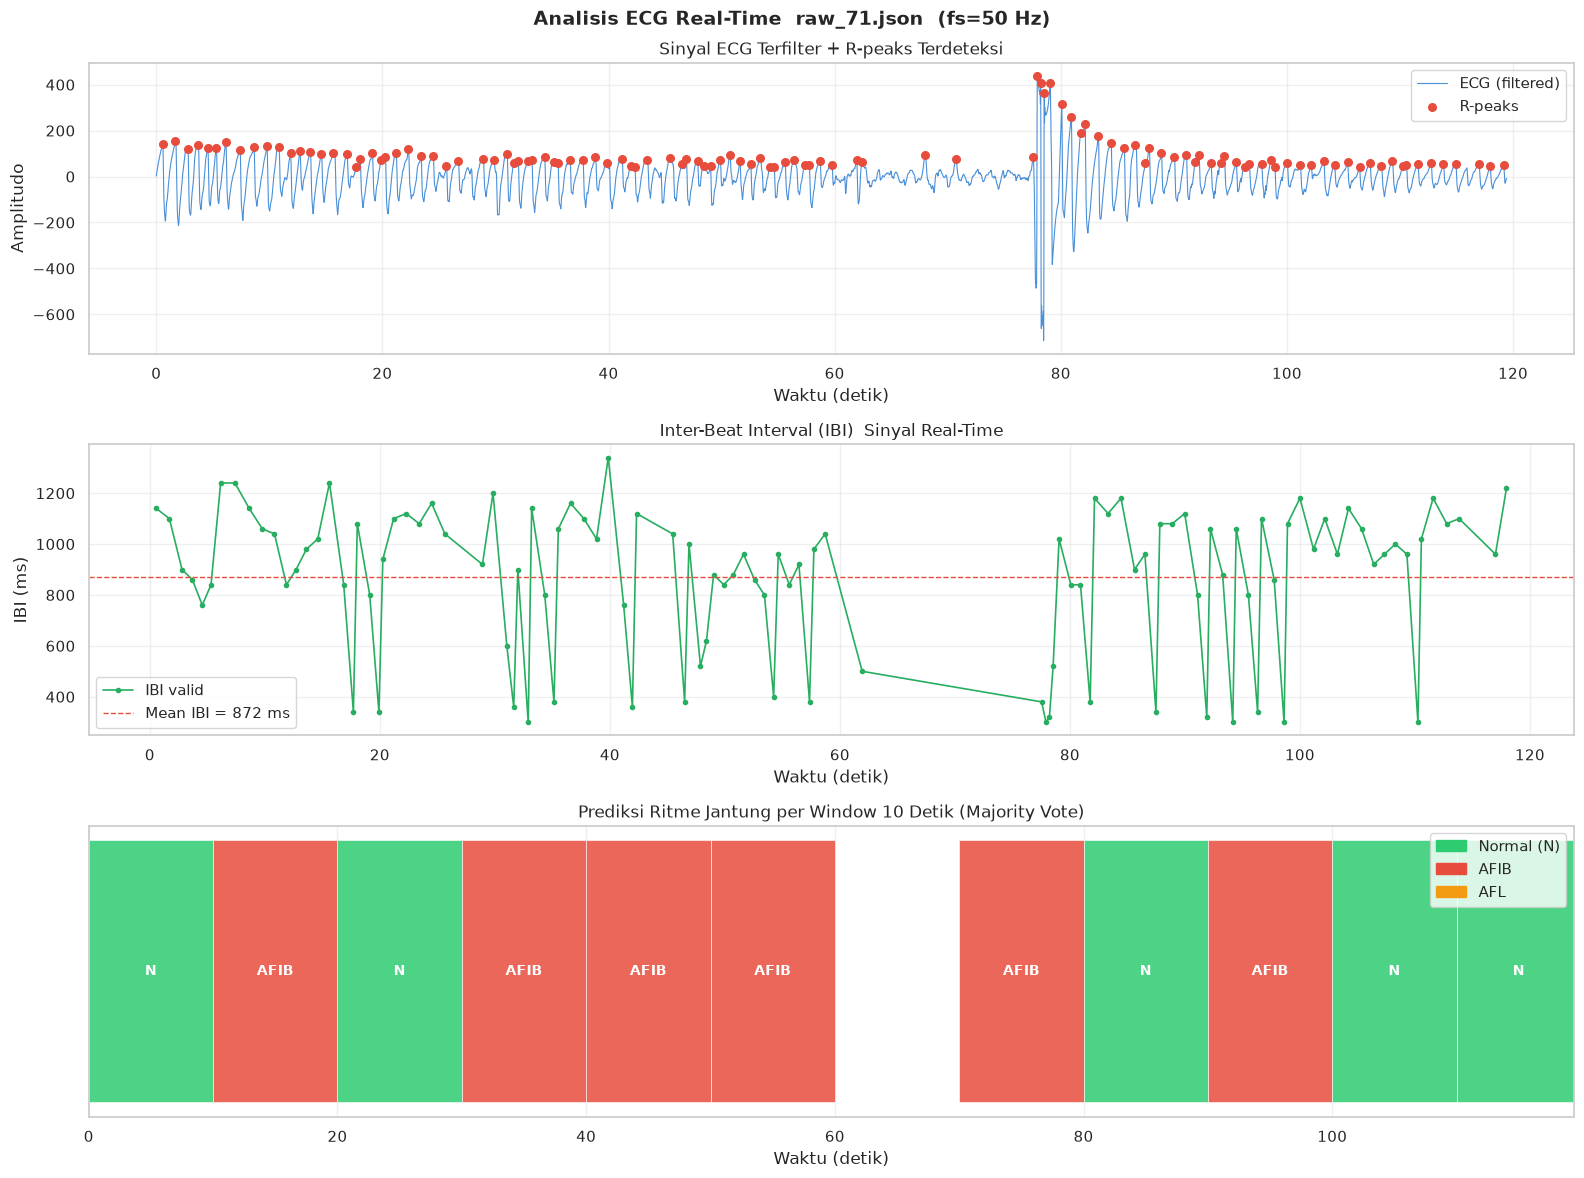

Tabel Fitur HRV + Prediksi:


,window_start_s,window_end_s,n_beats,mean_hr_bpm,mean_ibi,sdnn,rmssd,pred_majority_vote
0,0,10,10,58.37,1028.00,174.15,161.93,Normal (N)
1,10,20,11,70.06,856.36,284.93,367.10,AFIB
2,20,30,8,56.07,1070.00,99.14,142.03,Normal (N)
3,30,40,12,70.87,846.67,355.05,456.43,AFIB
4,40,50,10,79.79,752.00,272.31,456.27,AFIB
5,50,60,11,73.17,820.00,223.43,341.99,AFIB
6,70,80,5,118.11,508.00,298.86,272.40,AFIB
7,80,90,12,65.34,918.33,287.49,412.80,Normal (N)
8,90,100,12,80.90,741.67,332.32,568.95,AFIB
9,100,110,10,58.48,1026.00,88.47,123.47,Normal (N)


In [15]:
import json
import numpy as np
import pandas as pd
from scipy import signal as sp_signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# KONFIGURASI — Ubah path file JSON sesuai kebutuhan
# ============================================================
RAW_FILE = "raw_71.json"   # <- path ke file JSON raw ECG
FS_RAW   = 50              # <- sampling rate data real-time (Hz)
WINDOW_S = 10              # <- durasi window (detik)
MIN_BEATS = 4              # <- minimal detak per window agar dihitung

# Label mapping (sesuai training)
LABEL_MAP = {0: "Normal (N)", 1: "AFIB", 2: "AFL"}


# ============================================================
# STEP 1: Load data raw
# ============================================================
with open(RAW_FILE, "r") as f:
    raw_data = json.load(f)

ecg_raw = np.array(raw_data, dtype=float)
duration_s = len(ecg_raw) / FS_RAW
print(f"Data dimuat: {len(ecg_raw):,} sampel | Durasi: {duration_s:.1f} detik | fs={FS_RAW} Hz")


# ============================================================
# STEP 2: Clip outlier / artifact sensor
# ============================================================
p1  = np.percentile(ecg_raw, 1)
p99 = np.percentile(ecg_raw, 99)
ecg_clipped = np.clip(ecg_raw, p1, p99)
print(f"Clipping: [{p1:.1f}, {p99:.1f}]")


# ============================================================
# STEP 3: Bandpass filter 0.5-20 Hz
# (Batas atas 20 Hz < Nyquist 25 Hz untuk fs=50 Hz)
# ============================================================
low  = 0.5 / (FS_RAW / 2)
high = 20.0 / (FS_RAW / 2)
b, a = sp_signal.butter(2, [low, high], btype="bandpass")
ecg_filt = sp_signal.filtfilt(b, a, ecg_clipped)
print("Bandpass filter diterapkan (0.5-20 Hz)")


# ============================================================
# STEP 4: Deteksi R-peaks (adaptive threshold)
# ============================================================
mean_sig   = np.mean(ecg_filt)
std_sig    = np.std(ecg_filt)
threshold  = mean_sig + 0.5 * std_sig          # adaptive threshold
min_dist   = int(0.3 * FS_RAW)                # 300 ms -> max 200 bpm

peaks, _   = find_peaks(ecg_filt, height=threshold, distance=min_dist)
peak_times = peaks / FS_RAW                    # dalam detik
print(f"R-peaks terdeteksi: {len(peaks)} puncak")


# ============================================================
# STEP 5: Hitung IBI (ms) — filter fisiologis 300-2000 ms
# ============================================================
ibi_all   = np.diff(peaks) / FS_RAW * 1000     # konversi ke ms
ibi_times = peak_times[:-1]                     # waktu puncak pertama tiap pasangan

valid_mask = (ibi_all >= 300) & (ibi_all <= 2000)
ibi_valid  = ibi_all[valid_mask]
ibi_t_valid = ibi_times[valid_mask]

print(f"IBI valid: {len(ibi_valid)} dari {len(ibi_all)} ({valid_mask.mean()*100:.1f}%)")
if len(ibi_valid) > 0:
    avg_hr = 60000 / np.mean(ibi_valid)
    print(f"   Rata-rata HR: {avg_hr:.1f} bpm  |  IBI: {ibi_valid.min():.0f}-{ibi_valid.max():.0f} ms")


# ============================================================
# STEP 6: Windowing 10 detik & ekstraksi fitur HRV
# ============================================================
def extract_hrv_features(rr):
    mean_ibi   = np.mean(rr)
    median_ibi = np.median(rr)
    sdnn       = np.std(rr, ddof=1) if len(rr) > 1 else 0.0
    diff_rr    = np.diff(rr)
    rmssd      = np.sqrt(np.mean(diff_rr**2)) if len(diff_rr) > 0 else 0.0
    cv         = sdnn / mean_ibi if mean_ibi > 0 else 0.0
    mean_sd    = float(np.mean(np.abs(diff_rr))) if len(diff_rr) > 0 else 0.0
    std_sd     = float(np.std(np.abs(diff_rr), ddof=1)) if len(diff_rr) > 1 else 0.0

    # Turning Point Ratio
    if len(rr) > 2:
        turns = sum(
            1 for i in range(1, len(rr) - 1)
            if (rr[i] > rr[i-1] and rr[i] > rr[i+1]) or
               (rr[i] < rr[i-1] and rr[i] < rr[i+1])
        )
        tpr = turns / (len(rr) - 2)
    else:
        tpr = 0.0

    # Poincare Plot (SD1, SD2)
    if len(rr) > 1:
        x, y   = rr[:-1], rr[1:]
        sd1    = float(np.std((y - x) / np.sqrt(2), ddof=1))
        sd2    = float(np.std((y + x) / np.sqrt(2), ddof=1))
        sd1_sd2 = sd1 / sd2 if sd2 > 0 else 0.0
    else:
        sd1 = sd2 = sd1_sd2 = 0.0

    return {
        "mean_ibi":   mean_ibi,
        "median_ibi": median_ibi,
        "sdnn":       sdnn,
        "rmssd":      rmssd,
        "cv":         cv,
        "mean_sd":    mean_sd,
        "std_sd":     std_sd,
        "tpr":        tpr,
        "sd1":        sd1,
        "sd2":        sd2,
        "sd1_sd2":    sd1_sd2,
    }

windows_data = []
for w_start in range(0, int(duration_s), WINDOW_S):
    w_end = w_start + WINDOW_S
    mask  = (ibi_t_valid >= w_start) & (ibi_t_valid < w_end)
    ibi_w = ibi_valid[mask]
    if len(ibi_w) >= MIN_BEATS:
        feats = extract_hrv_features(ibi_w)
        feats["window_start_s"] = w_start
        feats["window_end_s"]   = w_end
        feats["n_beats"]        = len(ibi_w)
        feats["mean_hr_bpm"]    = 60000 / feats["mean_ibi"]
        windows_data.append(feats)

df_test = pd.DataFrame(windows_data)
print(f"Windows berhasil diekstraksi: {len(df_test)} window(s)")
print(df_test[["window_start_s", "window_end_s", "n_beats", "mean_hr_bpm",
               "mean_ibi", "sdnn", "rmssd"]].round(2).to_string(index=False))


# ============================================================
# STEP 7: Prediksi dengan 3 Model
# ============================================================
FEATURE_COLS = [
    "mean_ibi", "median_ibi", "sdnn", "rmssd", "cv",
    "mean_sd", "std_sd", "tpr", "sd1", "sd2", "sd1_sd2"
]

if df_test.empty:
    print("Tidak ada window yang cukup data untuk prediksi.")
else:
    X_realtime = df_test[FEATURE_COLS]

    results_list = []
    models = {
        "HistGradientBoosting": clf_pipeline,
        "Logistic Regression" : logreg_pipeline,
        "Random Forest"       : rf_pipeline,
    }

    print("=" * 65)
    print("  HASIL PREDIKSI DATA REAL-TIME")
    print("=" * 65)

    for model_name, model in models.items():
        preds  = model.predict(X_realtime)
        probas = model.predict_proba(X_realtime)

        print(f"Model: {model_name}")
        print("-" * 55)
        for i, row in df_test.iterrows():
            label_idx = preds[i - df_test.index[0]]
            prob_max  = probas[i - df_test.index[0]].max() * 100
            label_str = LABEL_MAP.get(label_idx, str(label_idx))
            w_s = int(row.window_start_s)
            w_e = int(row.window_end_s)
            hr  = row.mean_hr_bpm
            print(f"  Window [{w_s:3d}-{w_e:3d}s]  HR={hr:5.1f}bpm  -> Prediksi: {label_str:15s} ({prob_max:.1f}% confidence)")

        df_test[f"pred_{model_name.replace(' ', '_')}"] = preds

    # Majority vote lintas model
    pred_cols = [f"pred_{m.replace(' ', '_')}" for m in models]
    from scipy.stats import mode as scipy_mode
    df_test["pred_majority_vote"] = df_test[pred_cols].apply(
        lambda row: scipy_mode(row.values, keepdims=True).mode[0], axis=1
    )

    print("=" * 65)
    print("  RANGKUMAN MAJORITY VOTE (Konsensus 3 Model)")
    print("=" * 65)
    for _, row in df_test.iterrows():
        mv = LABEL_MAP.get(int(row.pred_majority_vote), str(int(row.pred_majority_vote)))
        w_s = int(row.window_start_s)
        w_e = int(row.window_end_s)
        print(f"  Window [{w_s:3d}-{w_e:3d}s] -> {mv}")


    # ============================================================
    # VISUALISASI
    # ============================================================
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f"Analisis ECG Real-Time  {RAW_FILE}  (fs={FS_RAW} Hz)",
                 fontsize=14, fontweight="bold")

    # Plot 1: Sinyal ECG + R-peaks
    ax1 = axes[0]
    t_axis = np.arange(len(ecg_filt)) / FS_RAW
    ax1.plot(t_axis, ecg_filt, color="#4A90D9", linewidth=0.8, label="ECG (filtered)")
    ax1.scatter(peak_times, ecg_filt[peaks], color="#E74C3C", s=30, zorder=5, label="R-peaks")
    ax1.set_xlabel("Waktu (detik)")
    ax1.set_ylabel("Amplitudo")
    ax1.set_title("Sinyal ECG Terfilter + R-peaks Terdeteksi")
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)

    # Plot 2: IBI per detak
    ax2 = axes[1]
    if len(ibi_valid) > 0:
        ax2.plot(ibi_t_valid, ibi_valid, color="#27AE60", linewidth=1.2,
                 marker="o", markersize=3, label="IBI valid")
        mean_ibi_val = np.mean(ibi_valid)
        ax2.axhline(mean_ibi_val, color="#E74C3C", linestyle="--",
                    linewidth=1, label=f"Mean IBI = {mean_ibi_val:.0f} ms")
        ax2.set_xlabel("Waktu (detik)")
        ax2.set_ylabel("IBI (ms)")
        ax2.set_title("Inter-Beat Interval (IBI)  Sinyal Real-Time")
        ax2.legend()
        ax2.grid(True, alpha=0.3)

    # Plot 3: Prediksi per window (Majority Vote)
    ax3 = axes[2]
    color_map = {0: "#2ECC71", 1: "#E74C3C", 2: "#F39C12"}
    label_abbrev = {0: "N", 1: "AFIB", 2: "AFL"}
    for _, row in df_test.iterrows():
        mv_label = int(row.pred_majority_vote)
        ax3.barh(
            y=0.5,
            width=WINDOW_S,
            left=row.window_start_s,
            height=0.9,
            color=color_map.get(mv_label, "#95A5A6"),
            edgecolor="white",
            linewidth=0.5,
            alpha=0.85
        )
        ax3.text(
            row.window_start_s + WINDOW_S/2, 0.5,
            label_abbrev.get(mv_label, "?"),
            ha="center", va="center",
            fontsize=10, fontweight="bold", color="white"
        )
    ax3.set_xlim(0, duration_s)
    ax3.set_ylim(0, 1)
    ax3.set_yticks([])
    ax3.set_xlabel("Waktu (detik)")
    ax3.set_title("Prediksi Ritme Jantung per Window 10 Detik (Majority Vote)")
    patches = [mpatches.Patch(color=c, label=LABEL_MAP[k]) for k, c in color_map.items()]
    ax3.legend(handles=patches, loc="upper right")
    ax3.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Tampilkan tabel ringkasan akhir
    print("Tabel Fitur HRV + Prediksi:")
    display_cols = ["window_start_s", "window_end_s", "n_beats", "mean_hr_bpm",
                    "mean_ibi", "sdnn", "rmssd", "pred_majority_vote"]
    df_disp = df_test[display_cols].copy()
    df_disp["pred_majority_vote"] = df_disp["pred_majority_vote"].map(LABEL_MAP)
    display(df_disp.round(2))

In [16]:
import joblib
import json
import hashlib
import os
import datetime
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import accuracy_score, f1_score

# ================================================================
#  EXPORT MODEL ENSEMBLE POHON KE BACKEND
#  Model: Random Forest + HistGradientBoosting
#  Format: .joblib (binary) + metadata.json (schema & info)
# ================================================================

OUTPUT_DIR = "model_export"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ----------------------------------------------------------------
# 1. Metadata & konfigurasi model
# ----------------------------------------------------------------
FEATURE_SCHEMA = [
    {"name": "mean_ibi",    "unit": "ms",    "description": "Rata-rata RR interval"},
    {"name": "median_ibi",  "unit": "ms",    "description": "Median RR interval"},
    {"name": "sdnn",        "unit": "ms",    "description": "Standar deviasi semua RR interval"},
    {"name": "rmssd",       "unit": "ms",    "description": "Root mean square successive differences"},
    {"name": "cv",          "unit": "ratio", "description": "Coefficient of variation (sdnn/mean_ibi)"},
    {"name": "mean_sd",     "unit": "ms",    "description": "Rata-rata selisih absolut successive differences"},
    {"name": "std_sd",      "unit": "ms",    "description": "Std successive differences"},
    {"name": "tpr",         "unit": "ratio", "description": "Turning point ratio"},
    {"name": "sd1",         "unit": "ms",    "description": "Poincare SD1 (short-term variability)"},
    {"name": "sd2",         "unit": "ms",    "description": "Poincare SD2 (long-term variability)"},
    {"name": "sd1_sd2",     "unit": "ratio", "description": "Rasio SD1/SD2"},
]

LABEL_SCHEMA = {
    "0": {"name": "N",    "full": "Normal Sinus Rhythm"},
    "1": {"name": "AFIB", "full": "Atrial Fibrillation"},
    "2": {"name": "AFL",  "full": "Atrial Flutter"},
}

PREPROCESSING_INFO = {
    "iqr_clipping": {
        "lower_percentile": 0.01,
        "upper_percentile": 0.99,
        "factor": 1.5,
        "note": "Safety net untuk artifact sensor"
    },
    "input_sampling_rate_train": "250 Hz (MIT-BIH LTAF database)",
    "input_sampling_rate_realtime": "50 Hz (compatible, IBI-based agnostic)",
    "window_duration_s": 10,
    "min_beats_per_window": 4,
    "ibi_range_valid_ms": [300, 2000],
}


# ----------------------------------------------------------------
# 2. Simpan model + hitung checksum SHA-256
# ----------------------------------------------------------------
def save_model_with_checksum(model, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    joblib.dump(model, path, compress=3)
    with open(path, "rb") as fh:
        sha256 = hashlib.sha256(fh.read()).hexdigest()
    size_kb = os.path.getsize(path) / 1024
    print(f"  {filename:<45} {size_kb:8.1f} KB  sha256={sha256[:16]}...")
    return {"file": filename, "sha256": sha256, "size_kb": round(size_kb, 2)}

print("Menyimpan model ke folder:", os.path.abspath(OUTPUT_DIR))
print("-" * 70)

models_info = {}
models_info["random_forest"]          = save_model_with_checksum(rf_pipeline,  "random_forest_pipeline.joblib")
models_info["hist_gradient_boosting"] = save_model_with_checksum(clf_pipeline, "hist_gradient_boosting_pipeline.joblib")


# ----------------------------------------------------------------
# 3. Evaluasi ringkas pada test set (untuk metadata performa)
# ----------------------------------------------------------------
perf_rf = {
    "accuracy":    round(accuracy_score(y_test_final, rf_pipeline.predict(X_test_final)), 4),
    "f1_macro":    round(f1_score(y_test_final, rf_pipeline.predict(X_test_final), average="macro"), 4),
    "f1_weighted": round(f1_score(y_test_final, rf_pipeline.predict(X_test_final), average="weighted"), 4),
}
perf_hgb = {
    "accuracy":    round(accuracy_score(y_test_final, clf_pipeline.predict(X_test_final)), 4),
    "f1_macro":    round(f1_score(y_test_final, clf_pipeline.predict(X_test_final), average="macro"), 4),
    "f1_weighted": round(f1_score(y_test_final, clf_pipeline.predict(X_test_final), average="weighted"), 4),
}

models_info["random_forest"]["performance"]          = perf_rf
models_info["hist_gradient_boosting"]["performance"] = perf_hgb

print()
print("Performa pada test set:")
print(f"  Random Forest            -> Acc={perf_rf['accuracy']:.4f}  F1-macro={perf_rf['f1_macro']:.4f}")
print(f"  HistGradientBoosting     -> Acc={perf_hgb['accuracy']:.4f}  F1-macro={perf_hgb['f1_macro']:.4f}")


# ----------------------------------------------------------------
# 4. Buat metadata.json lengkap (schema backend)
# ----------------------------------------------------------------
metadata = {
    "export_timestamp": datetime.datetime.now().isoformat(),
    "sklearn_version":  sklearn.__version__,
    "python_version":   f"{__import__('sys').version_info.major}.{__import__('sys').version_info.minor}",
    "model_type":       "tree_ensemble_pipeline",
    "models":           models_info,
    "input_schema": {
        "feature_order": [feat["name"] for feat in FEATURE_SCHEMA],
        "features":      FEATURE_SCHEMA,
        "example_request": {
            feat["name"]: round(float(X_test_final[feat["name"]].iloc[0]), 4)
            for feat in FEATURE_SCHEMA
        },
    },
    "output_schema": {
        "predict":       "integer (class index)",
        "predict_proba": "array[float] probabilitas tiap kelas",
        "label_map":     LABEL_SCHEMA,
    },
    "preprocessing":   PREPROCESSING_INFO,
    "recommended_use": (
        "Jalankan predict_proba pada kedua model, lalu kombinasikan dengan "
        "soft voting (rata-rata probabilitas) atau hard voting (majority vote)"
    ),
}

meta_path = os.path.join(OUTPUT_DIR, "metadata.json")
with open(meta_path, "w") as fh:
    json.dump(metadata, fh, indent=2, ensure_ascii=False)
print()
print("metadata.json tersimpan ->", os.path.abspath(meta_path))


# ----------------------------------------------------------------
# 5. Smoke-test: load ulang model & prediksi 3 sampel
# ----------------------------------------------------------------
print()
print("Smoke-test: memuat ulang model dari file dan prediksi 3 sampel...")

rf_loaded  = joblib.load(os.path.join(OUTPUT_DIR, "random_forest_pipeline.joblib"))
hgb_loaded = joblib.load(os.path.join(OUTPUT_DIR, "hist_gradient_boosting_pipeline.joblib"))

sample_X = X_test_final.head(3)
sample_y = y_test_final.head(3).values

label_full = {0: "Normal (N)", 1: "AFIB", 2: "AFL"}

header = f"  {'#':<4} {'True':>12} {'RF Pred':>12} {'HGB Pred':>12} {'Soft-Vote':>12}"
print(header)
print("  " + "-" * 60)

p_rf_s  = rf_loaded.predict_proba(sample_X)
p_hgb_s = hgb_loaded.predict_proba(sample_X)
avg_s   = (p_rf_s + p_hgb_s) / 2.0

for i in range(len(sample_X)):
    true_lbl = label_full.get(sample_y[i], str(sample_y[i]))
    rf_lbl   = label_full.get(rf_loaded.predict(sample_X.iloc[[i]])[0], "?")
    hgb_lbl  = label_full.get(hgb_loaded.predict(sample_X.iloc[[i]])[0], "?")
    sv_lbl   = label_full.get(int(np.argmax(avg_s[i])), "?")
    match    = "OK" if sv_lbl == true_lbl else "MISS"
    print(f"  [{i+1}]    {true_lbl:>12} {rf_lbl:>12} {hgb_lbl:>12} {sv_lbl:>12}  {match}")


# ----------------------------------------------------------------
# 6. Ringkasan isi folder export
# ----------------------------------------------------------------
print()
print(f"Isi folder export ({os.path.abspath(OUTPUT_DIR)}):")
print("-" * 70)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    fsize = os.path.getsize(fpath) / 1024
    print(f"  {fname:<50} {fsize:8.1f} KB")

print()
print("Export selesai, siap dikirim ke backend!")
print("Kirim seluruh folder 'model_export/' ke server backend.")

Menyimpan model ke folder: /home/gung/Dokumen/magang/model_export
----------------------------------------------------------------------
  random_forest_pipeline.joblib                   8108.6 KB  sha256=5ce8977cfb631541...
  hist_gradient_boosting_pipeline.joblib           193.6 KB  sha256=7949160c95283dfb...

Performa pada test set:
  Random Forest            -> Acc=0.9425  F1-macro=0.6268
  HistGradientBoosting     -> Acc=0.9448  F1-macro=0.6343

metadata.json tersimpan -> /home/gung/Dokumen/magang/model_export/metadata.json

Smoke-test: memuat ulang model dari file dan prediksi 3 sampel...
  #            True      RF Pred     HGB Pred    Soft-Vote
  ------------------------------------------------------------
  [1]      Normal (N)   Normal (N)   Normal (N)   Normal (N)  OK
  [2]      Normal (N)   Normal (N)   Normal (N)   Normal (N)  OK
  [3]      Normal (N)   Normal (N)   Normal (N)   Normal (N)  OK

Isi folder export (/home/gung/Dokumen/magang/model_export):
--------------------